In [1]:
%matplotlib inline

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("telemonitoring_parkinsons_updrs.data.csv")
df

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5870,42,61,0,142.7900,22.485,33.485,0.00406,0.000031,0.00167,0.00168,...,0.160,0.00973,0.01133,0.01549,0.02920,0.025137,22.369,0.64215,0.55314,0.21367
5871,42,61,0,149.8400,21.988,32.988,0.00297,0.000025,0.00119,0.00147,...,0.215,0.01052,0.01277,0.01904,0.03157,0.011927,22.886,0.52598,0.56518,0.12621
5872,42,61,0,156.8200,21.495,32.495,0.00349,0.000025,0.00152,0.00187,...,0.244,0.01371,0.01456,0.01877,0.04112,0.017701,25.065,0.47792,0.57888,0.14157
5873,42,61,0,163.7300,21.007,32.007,0.00281,0.000020,0.00128,0.00151,...,0.131,0.00693,0.00870,0.01307,0.02078,0.007984,24.422,0.56865,0.56327,0.14204


In [4]:
print(df.shape)
print(df.head())

(5875, 22)
   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179       0.00994   
2     0.000025     0.00205      0.00208  ...        0.181       0.00734   
3     0.000027     0.00191      0.00264  ...        0.327       0.01106   
4     0.000020     0.00093      0.00130  ...        0.176       0.00679   

   Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE  \
0       0.01309        0.

Text(0, 0.5, 'Number of Samples')

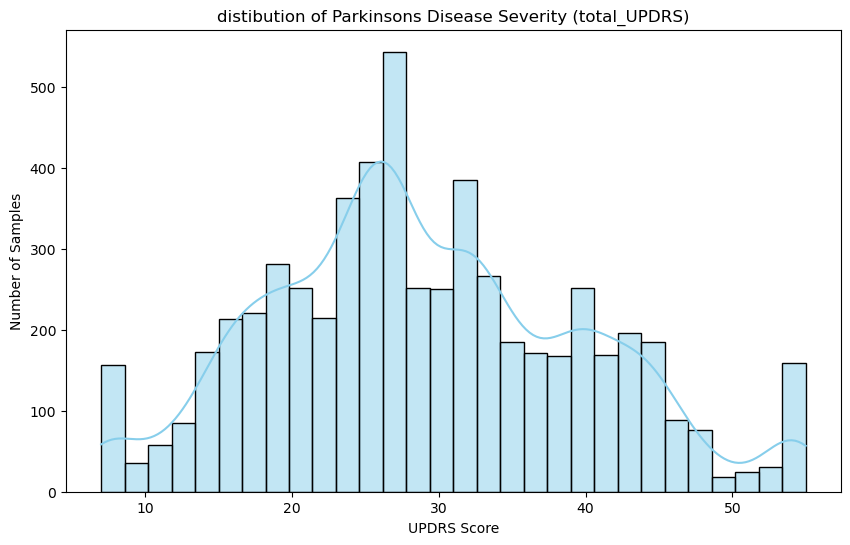

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['total_UPDRS'], bins=30, kde=True, color='skyblue')
plt.title('distibution of Parkinsons Disease Severity (total_UPDRS)')
plt.xlabel('UPDRS Score')
plt.ylabel('Number of Samples')

<Axes: ylabel='Count'>

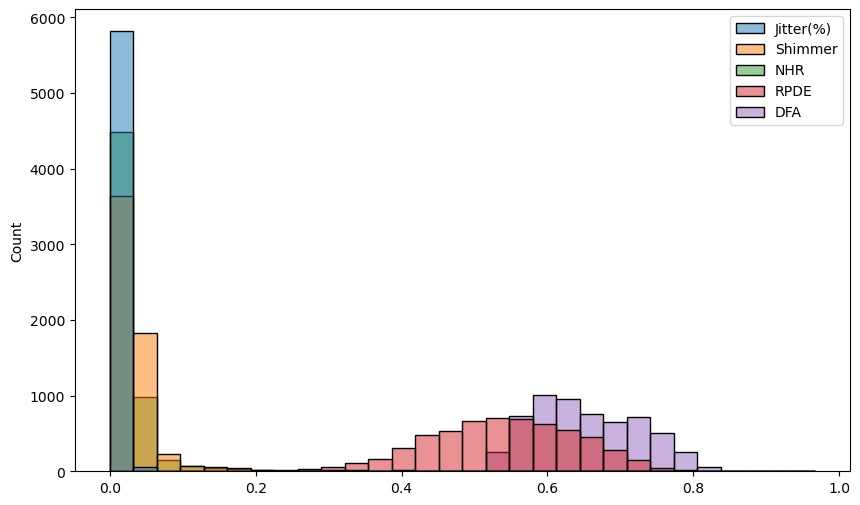

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
voice_features = ['Jitter(%)', 'Shimmer', 'NHR', 'RPDE', 'DFA']
plt.figure(figsize=(10, 6))
sns.histplot(df[voice_features], bins=30, edgecolor='black')


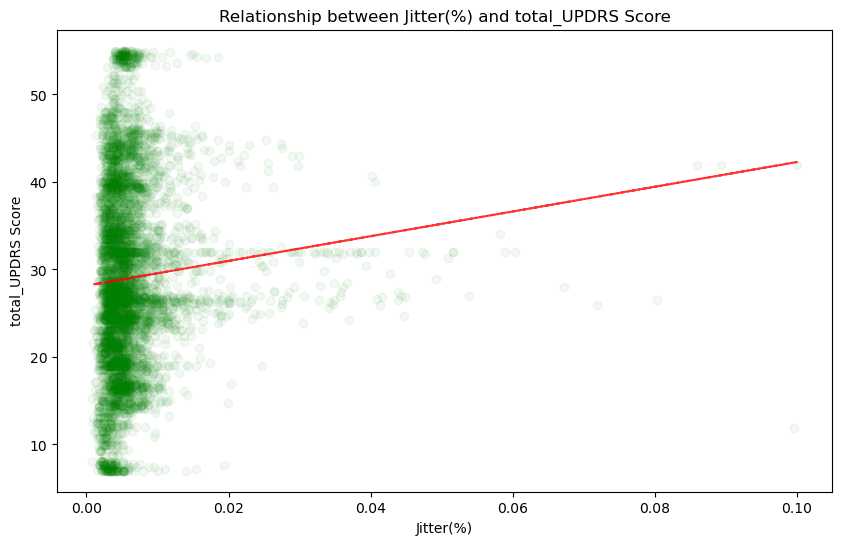

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Jitter(%)'], df['total_UPDRS'], alpha=0.05, color='green')
plt.title('Relationship between Jitter(%) and total_UPDRS Score')
plt.xlabel('Jitter(%)')
plt.ylabel('total_UPDRS Score')

z = np.polyfit(df['Jitter(%)'], df['total_UPDRS'], 1)
p = np.poly1d(z)
plt.plot(df['Jitter(%)'], p(df['Jitter(%)']), "r--", alpha=0.8)
plt.show()

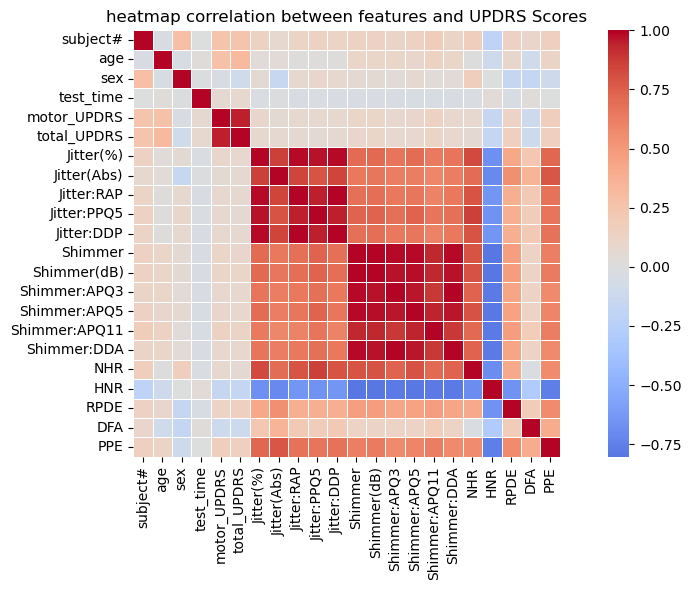

In [8]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('heatmap correlation between features and UPDRS Scores')
plt.tight_layout()
plt.show()

In [9]:
feature_cols = [col for col in df.columns if col not in ['subject', 'test_time', 'motor_UPDRS', 'total_UPDRS']]
X = df[feature_cols]
y = df['total_UPDRS']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()

In [37]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [38]:
y_pred = model.predict(X_test_scaled)

In [39]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'RMSE: {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')      

RMSE: 9.2866
R2 Score: 0.2217
